In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
df = pd.read_csv('/Users/parsa/Desktop/Thesis/Dataset/2023_Autoproduzione PV+FEV _estrattoDET.csv')
print (df.head(10))
df['Data'] = pd.to_datetime(df['DATA_RILEVAMENTO_BASE'], format='%m/%d/%y')
df['Ora'] = pd.to_datetime(df['ora_minuti'], format='%H:%M').dt.time
df['Data_Ora'] = pd.to_datetime(df['Data'].astype(str) + ' ' + df['Ora'].astype(str))
df['Data_Ora'] = pd.to_datetime(df['Data_Ora'], format='%Y-%m-%d %H:%M:%S')
df['Data_Ora'] = df['Data_Ora'].dt.tz_localize('Europe/Rome', nonexistent='shift_forward', ambiguous='NaT')
df['Data_Ora'] = df['Data_Ora'].dt.tz_convert('UTC')
df['Data_Ora'] = df['Data_Ora'].dt.tz_localize(None)
df['Data_Ora'] = pd.to_datetime(df['Data_Ora'], format='%Y-%m-%d %H:%M:%S')
df['Data_Ora'] = df['Data_Ora'].dt.tz_localize('UTC')
df['Data_Ora'] = df['Data_Ora'].dt.tz_convert('Europe/Rome')
df['Data_Ora'] = df['Data_Ora'].dt.tz_localize(None)
df['Data_Ora'] = pd.to_datetime(df['Data_Ora'], format='%Y-%m-%d %H:%M:%S') 

  DATA_ORA_MINUTI_RILEVAMENTO_BASE  anno  mese  giorno DATA_RILEVAMENTO_BASE  \
0                      1/1/23 0:00  2023     1       1                1/1/23   
1                      1/1/23 0:15  2023     1       1                1/1/23   
2                      1/1/23 0:30  2023     1       1                1/1/23   
3                      1/1/23 0:45  2023     1       1                1/1/23   
4                      1/1/23 1:00  2023     1       1                1/1/23   
5                      1/1/23 1:15  2023     1       1                1/1/23   
6                      1/1/23 1:30  2023     1       1                1/1/23   
7                      1/1/23 1:45  2023     1       1                1/1/23   
8                      1/1/23 2:00  2023     1       1                1/1/23   
9                      1/1/23 2:15  2023     1       1                1/1/23   

   num_giorno_sett  ora ora_minuti  minuti  ID_QUARTO_D_ORA  ...  \
0                7    0       0:00       0         

In [4]:
df.rename(columns={'DATA_ORA_MINUTI_RILEVAMENTO_BASE': 'DATE_TIME_MINUTES_BASE_DETECTION',
                   'anno': 'Year', 'mese': 'Month', 'giorno': 'Day', 'ora_minuti': 'Hour_Minutes',
                   'DATA_RILEVAMENTO_BASE': 'DATA_DETECTION_BASE', 'ora': 'Hour', 'minuti': 'Minutes', 'num_giorno_sett': 'num_day_week', 'ID_QUARTO_D_ORA' : 'ID_QUARTER_OF_HOUR' ,          })


,DATE_TIME_MINUTES_BASE_DETECTION,Year,Month,Day,DATA_DETECTION_BASE,num_day_week,Hour,Hour_Minutes,Minutes,ID_QUARTER_OF_HOUR,...,PV Ex Fucine,Fev-,PV Ex Fucine Est,PV Ex Fucine Ovest,PV Aule P,DIATI/DISAT,Aule R,Data,Ora,Data_Ora
0,1/1/23 0:00,2023,1,1,1/1/23,7,0,0:00,0,1,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:00:00,2023-01-01 00:00:00
1,1/1/23 0:15,2023,1,1,1/1/23,7,0,0:15,15,2,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:15:00,2023-01-01 00:15:00
2,1/1/23 0:30,2023,1,1,1/1/23,7,0,0:30,30,3,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:30:00,2023-01-01 00:30:00
3,1/1/23 0:45,2023,1,1,1/1/23,7,0,0:45,45,4,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:45:00,2023-01-01 00:45:00
4,1/1/23 1:00,2023,1,1,1/1/23,7,1,1:00,0,5,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,01:00:00,2023-01-01 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,12/31/23 22:45,2023,12,31,12/31/23,7,22,22:45,45,92,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,22:45:00,2023-12-31 22:45:00
35036,12/31/23 23:00,2023,12,31,12/31/23,7,23,23:00,0,93,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,23:00:00,2023-12-31 23:00:00
35037,12/31/23 23:15,2023,12,31,12/31/23,7,23,23:15,15,94,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,23:15:00,2023-12-31 23:15:00
35038,12/31/23 23:30,2023,12,31,12/31/23,7,23,23:30,30,95,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,23:30:00,2023-12-31 23:30:00


In [5]:
print(df.head(10))

  DATA_ORA_MINUTI_RILEVAMENTO_BASE  anno  mese  giorno DATA_RILEVAMENTO_BASE  \
0                      1/1/23 0:00  2023     1       1                1/1/23   
1                      1/1/23 0:15  2023     1       1                1/1/23   
2                      1/1/23 0:30  2023     1       1                1/1/23   
3                      1/1/23 0:45  2023     1       1                1/1/23   
4                      1/1/23 1:00  2023     1       1                1/1/23   
5                      1/1/23 1:15  2023     1       1                1/1/23   
6                      1/1/23 1:30  2023     1       1                1/1/23   
7                      1/1/23 1:45  2023     1       1                1/1/23   
8                      1/1/23 2:00  2023     1       1                1/1/23   
9                      1/1/23 2:15  2023     1       1                1/1/23   

   num_giorno_sett  ora ora_minuti  minuti  ID_QUARTO_D_ORA  ... PV Ex Fucine  \
0                7    0       0:00    

In [6]:
df

,DATA_ORA_MINUTI_RILEVAMENTO_BASE,anno,mese,giorno,DATA_RILEVAMENTO_BASE,num_giorno_sett,ora,ora_minuti,minuti,ID_QUARTO_D_ORA,...,PV Ex Fucine,Fev-,PV Ex Fucine Est,PV Ex Fucine Ovest,PV Aule P,DIATI/DISAT,Aule R,Data,Ora,Data_Ora
0,1/1/23 0:00,2023,1,1,1/1/23,7,0,0:00,0,1,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:00:00,2023-01-01 00:00:00
1,1/1/23 0:15,2023,1,1,1/1/23,7,0,0:15,15,2,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:15:00,2023-01-01 00:15:00
2,1/1/23 0:30,2023,1,1,1/1/23,7,0,0:30,30,3,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:30:00,2023-01-01 00:30:00
3,1/1/23 0:45,2023,1,1,1/1/23,7,0,0:45,45,4,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,00:45:00,2023-01-01 00:45:00
4,1/1/23 1:00,2023,1,1,1/1/23,7,1,1:00,0,5,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-01-01,01:00:00,2023-01-01 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,12/31/23 22:45,2023,12,31,12/31/23,7,22,22:45,45,92,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,22:45:00,2023-12-31 22:45:00
35036,12/31/23 23:00,2023,12,31,12/31/23,7,23,23:00,0,93,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,23:00:00,2023-12-31 23:00:00
35037,12/31/23 23:15,2023,12,31,12/31/23,7,23,23:15,15,94,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,23:15:00,2023-12-31 23:15:00
35038,12/31/23 23:30,2023,12,31,12/31/23,7,23,23:30,30,95,...,0.0,0,0.0,0.0,0.0,0.0,0.0,2023-12-31,23:30:00,2023-12-31 23:30:00


In [7]:
df.columns

Index(['DATA_ORA_MINUTI_RILEVAMENTO_BASE', 'anno', 'mese', 'giorno',
       'DATA_RILEVAMENTO_BASE', 'num_giorno_sett', 'ora', 'ora_minuti',
       'minuti', 'ID_QUARTO_D_ORA', 'festivo', 'FasciaAEEG',
       'DATA_ORA_MINUTI_RILEVAMENTO_BASE_nodst', 'Fabbisogno', 'Prelievo',
       'Autoproduzione', 'Autoproduzione_PV', 'PV Cittadella', 'PV Ex Fucine',
       'Fev-', 'PV Ex Fucine Est', 'PV Ex Fucine Ovest', 'PV Aule P',
       'DIATI/DISAT', 'Aule R', 'Data', 'Ora', 'Data_Ora'],
      dtype='object')

In [8]:
df_sub= df[['giorno', 'minuti', 'mese']]
df_sub

,giorno,minuti,mese
0,1,0,1
1,1,15,1
2,1,30,1
3,1,45,1
4,1,0,1
...,...,...,...
35035,31,45,12
35036,31,0,12
35037,31,15,12
35038,31,30,12


Index(['giorno', 'minuti', 'mese'], dtype='object')


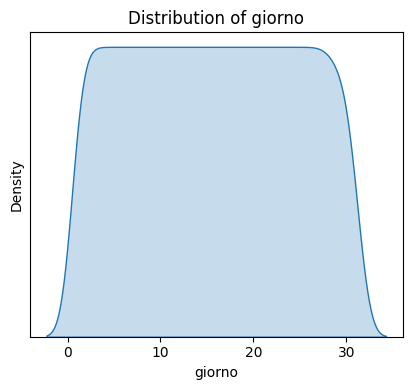

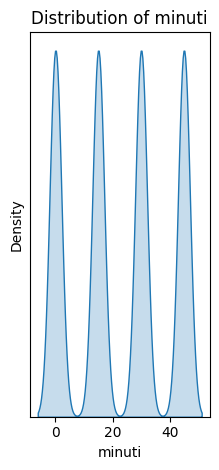

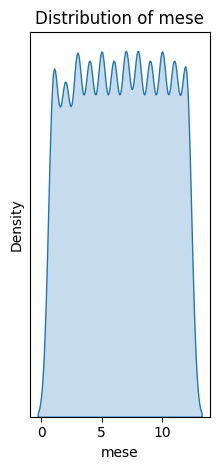

In [9]:
coloumns_to_scale= df_sub.columns
print(coloumns_to_scale)
plt.figure(figsize=(12, 4))
for i in range(len(df_sub.columns)):
    plt.subplot(1,3,i+1)
    sns.kdeplot(x=coloumns_to_scale[i], data=df_sub, fill=True)
    plt.title(f'Distribution of {coloumns_to_scale[i]}')
    plt.yticks([])
    plt.tight_layout()
    plt.show()

Index(['giorno', 'minuti', 'mese'], dtype='object')


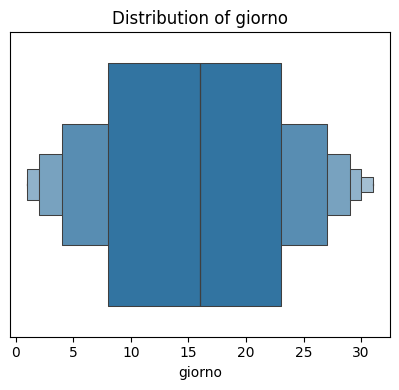

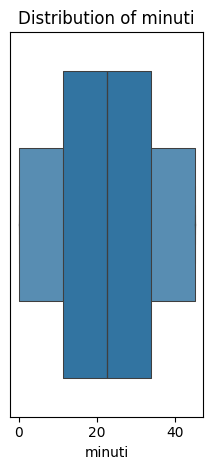

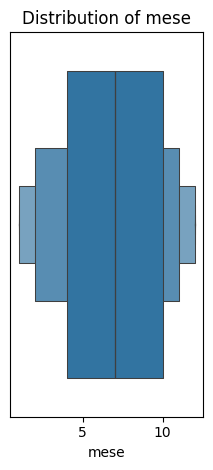

In [10]:
coloumns_to_scale= df_sub.columns
print(coloumns_to_scale)
plt.figure(figsize=(12, 4))
for i in range(len(df_sub.columns)):
    plt.subplot(1,3,i+1)
    sns.boxenplot(x=coloumns_to_scale[i], data=df_sub, fill=True)
    plt.title(f'Distribution of {coloumns_to_scale[i]}')
    plt.yticks([])
    plt.tight_layout()
    plt.show()

In [11]:
scaler1= StandardScaler()
scaler1.fit_transform(df_sub)

array([[-1.67350325, -1.34164079, -1.60274527],
       [-1.67350325, -0.4472136 , -1.60274527],
       [-1.67350325,  0.4472136 , -1.60274527],
       ...,
       [ 1.73704218, -0.4472136 ,  1.58764752],
       [ 1.73704218,  0.4472136 ,  1.58764752],
       [ 1.73704218,  1.34164079,  1.58764752]], shape=(35040, 3))

In [12]:
scaled_output1= pd.DataFrame(scaler1.transform(df_sub), columns=df_sub.columns)
scaled_output1

,giorno,minuti,mese
0,-1.673503,-1.341641,-1.602745
1,-1.673503,-0.447214,-1.602745
2,-1.673503,0.447214,-1.602745
3,-1.673503,1.341641,-1.602745
4,-1.673503,-1.341641,-1.602745
...,...,...,...
35035,1.737042,1.341641,1.587648
35036,1.737042,-1.341641,1.587648
35037,1.737042,-0.447214,1.587648
35038,1.737042,0.447214,1.587648


Index(['giorno', 'minuti', 'mese'], dtype='object')


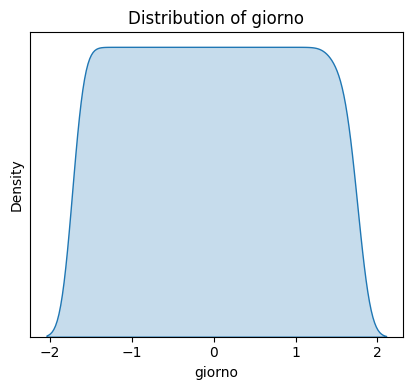

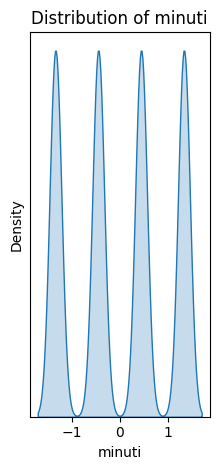

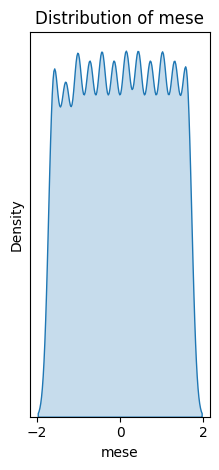

In [13]:
coloumns_to_scale= df_sub.columns
print(coloumns_to_scale)
plt.figure(figsize=(12, 4))
for i in range(len(df_sub.columns)):
    plt.subplot(1,3,i+1)
    sns.kdeplot(x=coloumns_to_scale[i], data=scaled_output1, fill=True)
    plt.title(f'Distribution of {coloumns_to_scale[i]}')
    plt.yticks([])
    plt.tight_layout()
    plt.show()

In [14]:
scaler2= MinMaxScaler()
scaler2.fit_transform(df_sub)
scaled_output2= pd.DataFrame(scaler2.transform(df_sub), columns=df_sub.columns)
scaled_output2

,giorno,minuti,mese
0,0.0,0.000000,0.0
1,0.0,0.333333,0.0
2,0.0,0.666667,0.0
3,0.0,1.000000,0.0
4,0.0,0.000000,0.0
...,...,...,...
35035,1.0,1.000000,1.0
35036,1.0,0.000000,1.0
35037,1.0,0.333333,1.0
35038,1.0,0.666667,1.0


Index(['giorno', 'minuti', 'mese'], dtype='object')


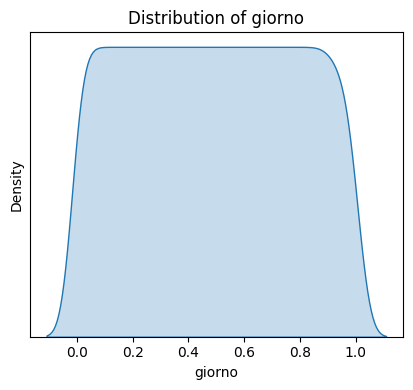

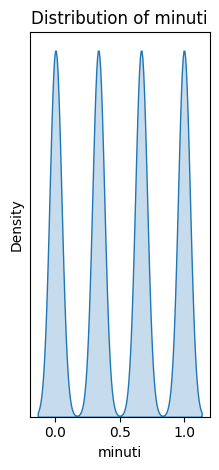

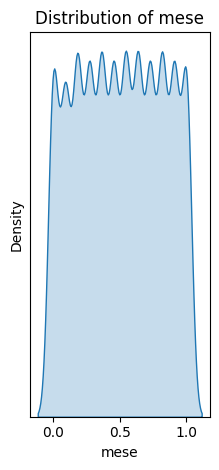

In [15]:
coloumns_to_scale= df_sub.columns
print(coloumns_to_scale)
plt.figure(figsize=(12, 4))
for i in range(len(df_sub.columns)):
    plt.subplot(1,3,i+1)
    sns.kdeplot(x=coloumns_to_scale[i], data=scaled_output2, fill=True)
    plt.title(f'Distribution of {coloumns_to_scale[i]}')
    plt.yticks([])
    plt.tight_layout()
    plt.show()

In [16]:
df_sub.mean()

giorno    15.720548
minuti    22.500000
mese       6.526027
dtype: float64

In [17]:
df_sub.shape

(35040, 3)

In [18]:
df_sub.describe()
df_sub.head(10)

,giorno,minuti,mese
0,1,0,1
1,1,15,1
2,1,30,1
3,1,45,1
4,1,0,1
5,1,15,1
6,1,30,1
7,1,45,1
8,1,0,1
9,1,15,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 28 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   DATA_ORA_MINUTI_RILEVAMENTO_BASE        35040 non-null  object        
 1   anno                                    35040 non-null  int64         
 2   mese                                    35040 non-null  int64         
 3   giorno                                  35040 non-null  int64         
 4   DATA_RILEVAMENTO_BASE                   35040 non-null  object        
 5   num_giorno_sett                         35040 non-null  int64         
 6   ora                                     35040 non-null  int64         
 7   ora_minuti                              35040 non-null  object        
 8   minuti                                  35040 non-null  int64         
 9   ID_QUARTO_D_ORA                         35040 non-

In [20]:
df.isnull().sum()

DATA_ORA_MINUTI_RILEVAMENTO_BASE          0
anno                                      0
mese                                      0
giorno                                    0
DATA_RILEVAMENTO_BASE                     0
num_giorno_sett                           0
ora                                       0
ora_minuti                                0
minuti                                    0
ID_QUARTO_D_ORA                           0
festivo                                   0
FasciaAEEG                                0
DATA_ORA_MINUTI_RILEVAMENTO_BASE_nodst    0
Fabbisogno                                0
Prelievo                                  0
Autoproduzione                            0
Autoproduzione_PV                         0
PV Cittadella                             0
PV Ex Fucine                              0
Fev-                                      0
PV Ex Fucine Est                          0
PV Ex Fucine Ovest                        0
PV Aule P                       

In [21]:
(df.isnull().sum()*100/df.index.size).round(2).sort_values(ascending=False)

Data_Ora                                  0.01
anno                                      0.00
Ora                                       0.00
Data                                      0.00
Aule R                                    0.00
DIATI/DISAT                               0.00
PV Aule P                                 0.00
PV Ex Fucine Ovest                        0.00
PV Ex Fucine Est                          0.00
Fev-                                      0.00
PV Ex Fucine                              0.00
PV Cittadella                             0.00
Autoproduzione_PV                         0.00
Autoproduzione                            0.00
DATA_ORA_MINUTI_RILEVAMENTO_BASE          0.00
Fabbisogno                                0.00
DATA_ORA_MINUTI_RILEVAMENTO_BASE_nodst    0.00
FasciaAEEG                                0.00
festivo                                   0.00
ID_QUARTO_D_ORA                           0.00
minuti                                    0.00
ora_minuti   

In [22]:
df.isnull().sum(axis=1).sum()

np.int64(4)

In [23]:
df[df.isnull().any(axis=1)].index

Index([28904, 28905, 28906, 28907], dtype='int64')

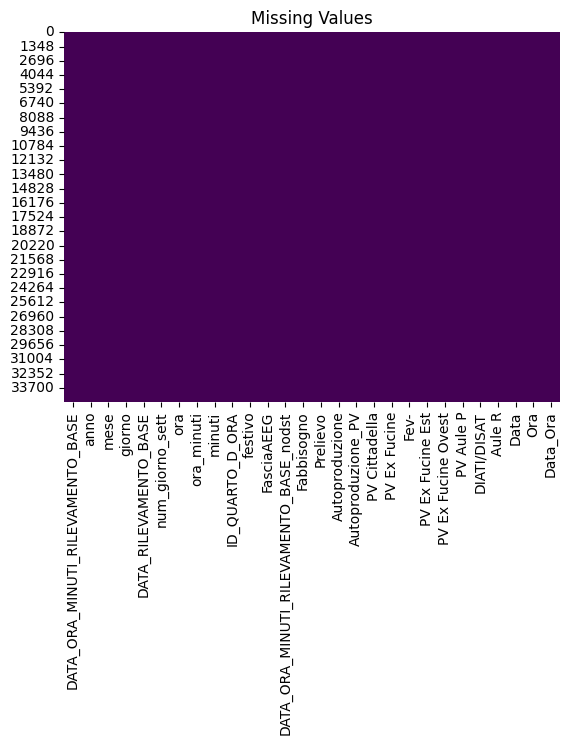

In [24]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values')
plt.show()

In [25]:
dffill=df.copy()
dffill.ffill(inplace=True)
dffill.isnull().sum()

DATA_ORA_MINUTI_RILEVAMENTO_BASE          0
anno                                      0
mese                                      0
giorno                                    0
DATA_RILEVAMENTO_BASE                     0
num_giorno_sett                           0
ora                                       0
ora_minuti                                0
minuti                                    0
ID_QUARTO_D_ORA                           0
festivo                                   0
FasciaAEEG                                0
DATA_ORA_MINUTI_RILEVAMENTO_BASE_nodst    0
Fabbisogno                                0
Prelievo                                  0
Autoproduzione                            0
Autoproduzione_PV                         0
PV Cittadella                             0
PV Ex Fucine                              0
Fev-                                      0
PV Ex Fucine Est                          0
PV Ex Fucine Ovest                        0
PV Aule P                       